# Assignment 25: Lung Cancer Classification Case Study

## Objective
Classify lung cancer instances using three different algorithms: **Gaussian Naive Bayes**, **Decision Tree**, and **MLP Classifier** (Neural Network).

## Dataset
We use the **Lung Cancer** dataset (available via OpenML or UCI). 
> **Note**: This dataset is **very small** (only 32 instances). This is common in medical case studies but challenges machine learning models to generalize without overfitting.

## Strategy for Efficiency
1.  **Code Reuse**: We will write a single function to train and evaluate models, avoiding repetitive code.
2.  **Visualization**: We will visually compare confusion matrices and accuracy scores.
3.  **Data Caching**: The dataset will be saved locally so you don't need to download it every time.

In [1]:
import numpy as np
import pandas as pd
import os
import requests
from io import StringIO

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder

from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Set plot style for better visuals
plt.style.use('ggplot')

In [2]:
# --- 1. Efficient Data Loading with Caching ---
DATA_FILE = "lung_cancer_data.csv"

def load_data():
    # If file exists locally, load it
    if os.path.exists(DATA_FILE):
        print(f"Loading data from local cache: {DATA_FILE}")
        return pd.read_csv(DATA_FILE)
    
    print("Downloading data... this may take a moment.")
    # Attempt OpenML first
    try:
        from sklearn.datasets import fetch_openml
        X, y = fetch_openml(name="lung-cancer", as_frame=True, return_X_y=True)
        df = X.copy()
        df['target'] = y
        # Save for next time
        df.to_csv(DATA_FILE, index=False)
        print("Downloaded via OpenML and saved.")
        return df
    except Exception:
        print("OpenML failed, trying UCI mirror...")
    
    # Fallback to UCI mirror
    uci_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/lung-cancer.csv"
    try:
        resp = requests.get(uci_url, timeout=10)
        df = pd.read_csv(StringIO(resp.text), header=None)
        df = df.replace("?", np.nan)
        # Rename first column to 'target' (assumed for UCI version)
        df.rename(columns={0: 'target'}, inplace=True)
        df.to_csv(DATA_FILE, index=False)
        print("Downloaded via UCI and saved.")
        return df
    except Exception as e:
        print(f"Error: {e}")
        return None

df = load_data()
print(f"Dataset Shape: {df.shape}")
print(f"Target Classes: {df['target'].unique()}")

Downloaded via OpenML and saved.
Dataset Shape: (32, 57)
Target Classes: ['1', '2', '3']
Categories (3, object): ['1', '2', '3']


In [3]:
# --- 2. Preprocessing ---
# Separate Target and Features
y = df['target']
X = df.drop(columns=['target'])

# Ensure target is numeric for compatibility
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# Identify columns
# In this dataset, most are integer strings or numeric. Converting safely:
X = X.apply(pd.to_numeric, errors='coerce')
numeric_cols = X.columns[X.notna().all()].tolist()
cat_cols = [c for c in X.columns if c not in numeric_cols]

# Pipelines
# For NB and MLP: Impute + Scale
prep_scaled = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), numeric_cols),
    ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols)
])

# For Decision Tree: Just Impute (Scaling not needed, but doesn't hurt)
prep_tree = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), numeric_cols),
    ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols)
])

# Train-Test Split
# Given small size (32 rows), stratify might fail if a class has 1 sample. 
# We try-catch stratify.
try:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
except ValueError:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 24, Test size: 8


In [4]:
# --- 3. Efficient Model Evaluation Function ---
results = {}

def train_evaluate(name, pipeline):
    """
    Trains the pipeline, makes predictions, prints report, and stores accuracy.
    """
    print(f"\n--- Training {name} ---")
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"Accuracy: {acc:.4f}")
    print("Confusion Matrix:")
    # Determine labels (dynamic based on what's in y_test)
    labels = np.unique(np.concatenate((y_test, y_pred)))
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    print(cm)
    return pipeline

# Define Models
models = [
    ("Gaussian NB", Pipeline([('prep', prep_scaled), ('clf', GaussianNB())])),
    ("Decision Tree", Pipeline([('prep', prep_tree), ('clf', DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42))])),
    ("MLP Classifier", Pipeline([('prep', prep_scaled), ('clf', MLPClassifier(hidden_layer_sizes=(64,32), max_iter=1000, random_state=42))]))
]

# Loop through models
trained_models = []
for name, pipe in models:
    trained_models.append(train_evaluate(name, pipe))


--- Training Gaussian NB ---
Accuracy: 0.6250
Confusion Matrix:
[[0 1 1]
 [1 2 0]
 [0 0 3]]

--- Training Decision Tree ---
Accuracy: 0.5000
Confusion Matrix:
[[0 1 1]
 [2 1 0]
 [0 0 3]]

--- Training MLP Classifier ---
Accuracy: 0.5000
Confusion Matrix:
[[1 1 0]
 [1 1 1]
 [0 1 2]]


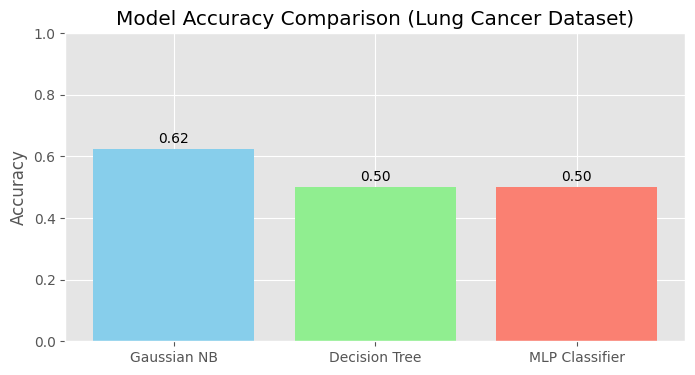

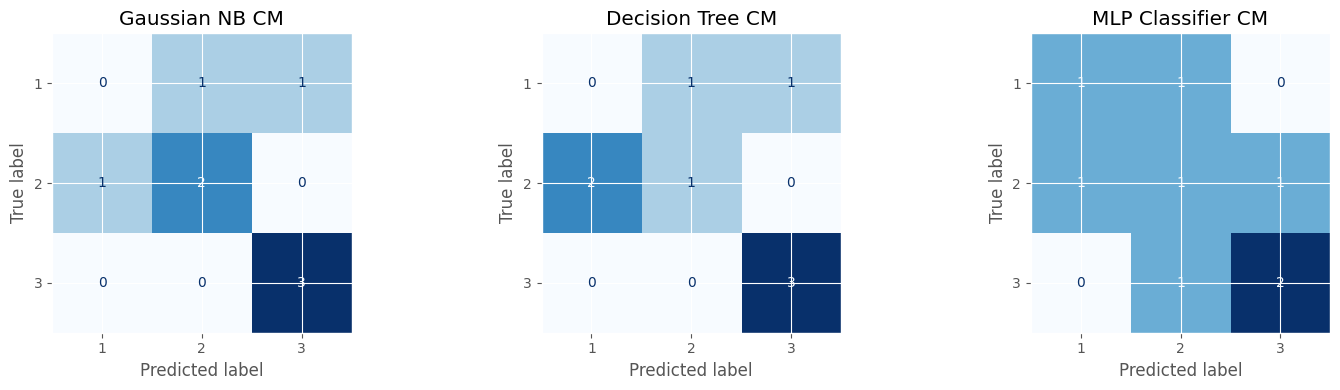

In [5]:
# --- 4. Visualization & Comparison ---

# Bar Chart
plt.figure(figsize=(8, 4))
plt.bar(results.keys(), results.values(), color=['skyblue', 'lightgreen', 'salmon'])
plt.title("Model Accuracy Comparison (Lung Cancer Dataset)")
plt.ylabel("Accuracy")
plt.ylim(0, 1.0)
for i, v in enumerate(results.values()):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')
plt.show()

# Side-by-Side Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (name, pipe) in enumerate(zip(results.keys(), trained_models)):
    y_pred = pipe.predict(X_test)
    labels = np.unique(np.concatenate((y_test, y_pred)))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, 
        ax=axes[i], 
        cmap='Blues', 
        colorbar=False,
        labels=labels
    )
    axes[i].set_title(f"{name} CM")

plt.tight_layout()
plt.show()